# Main Figures — Boxplots and Correlation Scatter Plots

Produces eight figures: four grouped boxplots comparing the three experimental groups
(No Resource, PDF, ChatGPT) across primary outcome domains, plus four scatter plots
examining the relationship between self-confidence and knowledge score.

**Input:** `../data/processed/survey_clean.csv`  
**Output:** `../figures/main_boxplots/fig1_knowledge_outcomes.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/main_boxplots/fig2_pct_correct.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/main_boxplots/fig3_completion_time.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/main_boxplots/fig4_self_assessment.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/correlation/fig5_corr_all.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/correlation/fig6_corr_no_resource.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/correlation/fig7_corr_pdf.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/correlation/fig8_corr_chatgpt.[png|pdf]`

**Visualization approach (Figures 1–4):** Grouped boxplots with individual data
points overlaid via `seaborn.stripplot` are used so the full distribution is visible
even with small group sizes (n = 5–7). Statistical significance is reported in the
tables (see `02.summary_table.ipynb`); these figures serve as a visual complement.

| Figure | Type    | Variables / Subset                                               | Scale        |
|--------|---------|------------------------------------------------------------------|--------------|
| 1      | Boxplot | n_correct, n_incorrect, n_not_sure                               | Count (0–12) |
| 2      | Boxplot | pct_correct_of_attempted                                         | Percent (0–100) |
| 3      | Boxplot | duration_min                                                     | Minutes      |
| 4      | Boxplot | self_knowledge_tdi, self_confidence_*                            | Rating (0–10)|
| 5      | Scatter | self_confidence_mean vs n_correct — All Participants (n = 18)   | —            |
| 6      | Scatter | self_confidence_mean vs n_correct — No Resource (n = 7)         | —            |
| 7      | Scatter | self_confidence_mean vs n_correct — PDF (n = 5)                 | —            |
| 8      | Scatter | self_confidence_mean vs n_correct — ChatGPT (n = 6)             | —            |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Theme ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="white", font_scale=1.4)

# ── Constants ─────────────────────────────────────────────────────────────────
HUE_ORDER = ["No Resource", "PDF", "ChatGPT"]
HUE_PALETTE = {"No Resource": "#F8766D", "PDF": "#CD9600", "ChatGPT": "#00A9FF"}

FLIERPROPS = dict(marker="", markersize=0)  # hide default outlier markers
STRIP_KWS  = dict(jitter=True, alpha=0.6, dodge=True, linewidth=0.5)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path("../data/processed/survey_clean.csv")
OUT_DIR   = Path("../figures/main_boxplots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df["group_label"] = pd.Categorical(df["group_label"], categories=HUE_ORDER, ordered=True)

print(f"Loaded {len(df)} rows. Groups: {df['group_label'].value_counts().to_dict()}")
df[["n_correct", "n_incorrect", "n_not_sure",
    "pct_correct_of_attempted", "duration_min",
    "self_knowledge_tdi", "self_confidence_avulsion",
    "self_confidence_fracture", "self_confidence_mean"]].describe()

Loaded 18 rows. Groups: {'No Resource': 7, 'ChatGPT': 6, 'PDF': 5}


,n_correct,n_incorrect,n_not_sure,pct_correct_of_attempted,duration_min,self_knowledge_tdi,self_confidence_avulsion,self_confidence_fracture,self_confidence_mean
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,8.222222,3.333333,0.444444,70.744444,19.357222,4.111111,4.722222,4.555556,4.462222
std,1.832888,1.371989,1.149026,12.269964,29.290747,2.928338,3.139980,3.110177,2.958172
min,5.000000,1.000000,0.000000,50.000000,2.970000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,2.250000,0.000000,62.775000,6.032500,2.000000,2.000000,2.250000,1.835000
50%,8.000000,3.500000,0.000000,66.700000,8.260000,3.000000,5.500000,5.000000,4.165000
75%,9.750000,4.000000,0.000000,81.225000,14.692500,6.750000,7.000000,6.000000,6.330000
max,11.000000,6.000000,4.000000,91.700000,107.050000,9.000000,9.000000,10.000000,9.330000


## Figure 1 — Knowledge Outcomes by Group

Three x-axis categories: Total Correct (`n_correct`), Total Incorrect (`n_incorrect`),
Total Not Sure (`n_not_sure`). Each group's box spans Q1–Q3 with individual participant
data points overlaid to show the full distribution (n = 5–7 per group).

This figure also carries the shared legend used for all four boxplot figures.

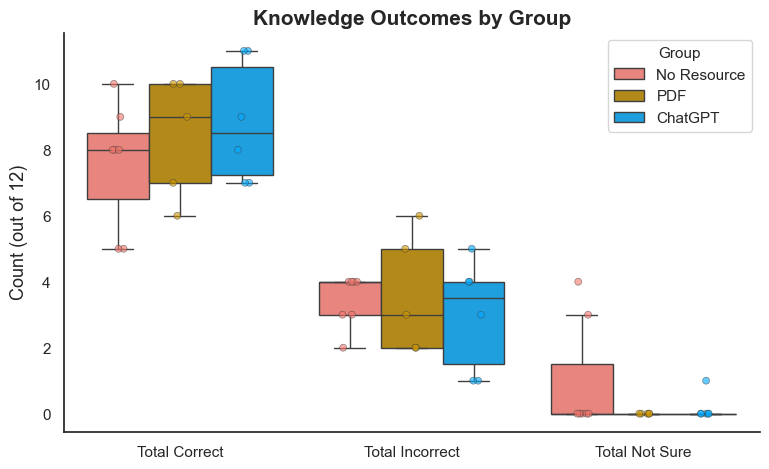

Saved fig1_knowledge_outcomes


In [2]:
# Melt to long format
fig1_vars = {
    "n_correct":   "Total Correct",
    "n_incorrect": "Total Incorrect",
    "n_not_sure":  "Total Not Sure",
}
df_fig1 = (
    df[["group_label"] + list(fig1_vars)]
    .melt(id_vars="group_label", var_name="_col", value_name="count")
    .assign(metric=lambda x: x["_col"].map(fig1_vars))
)
df_fig1["metric"] = pd.Categorical(
    df_fig1["metric"], categories=list(fig1_vars.values()), ordered=True
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_fig1, x="metric", y="count", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig1, x="metric", y="count", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Knowledge Outcomes by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Count (out of 12)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)

# Keep only one legend (strip duplicates the boxplot legend)
handles, labels = ax.get_legend_handles_labels()
n_groups = len(HUE_ORDER)
legend = ax.legend(
    handles[:n_groups], labels[:n_groups],
    title="Group", loc="upper right",
    fontsize=11, title_fontsize=11,
)

plt.tight_layout()
fig.savefig(OUT_DIR / "fig1_knowledge_outcomes.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig1_knowledge_outcomes.pdf", bbox_inches="tight")
plt.show()
print("Saved fig1_knowledge_outcomes")

## Figure 2 — Percent Correct of Attempted by Group

Single x-axis category; y-axis is 0–100 % (different scale from Figure 1).  
`pct_correct_of_attempted` excludes "not sure" responses from the denominator,  
giving a measure of accuracy among questions the participant attempted to answer.

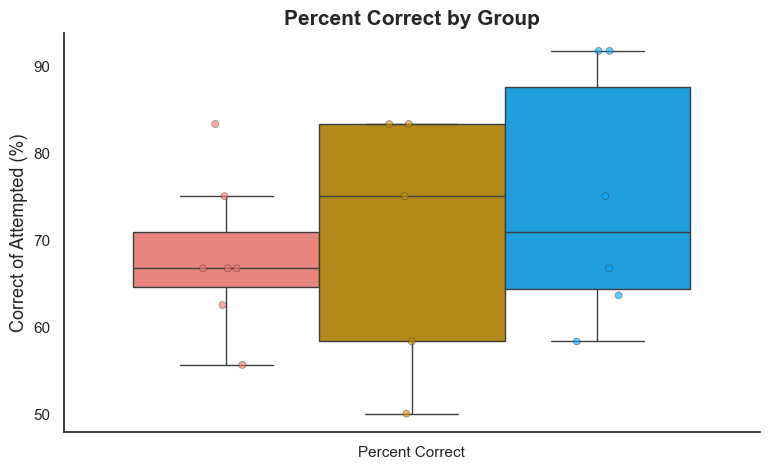

Saved fig2_pct_correct


In [3]:
df_fig2 = df[["group_label", "pct_correct_of_attempted"]].copy()
df_fig2["metric"] = "Percent Correct"

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_fig2, x="metric", y="pct_correct_of_attempted", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig2, x="metric", y="pct_correct_of_attempted", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Percent Correct by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Correct of Attempted (%)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
ax.get_legend().remove()

plt.tight_layout()
fig.savefig(OUT_DIR / "fig2_pct_correct.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig2_pct_correct.pdf", bbox_inches="tight")
plt.show()
print("Saved fig2_pct_correct")

## Figure 3 — Completion Time by Group

Single x-axis category; y-axis in minutes (`duration_min`).  
Completion time reflects how long each participant spent on the survey,  
which may vary by resource type (e.g., ChatGPT group may take longer to consult the tool).

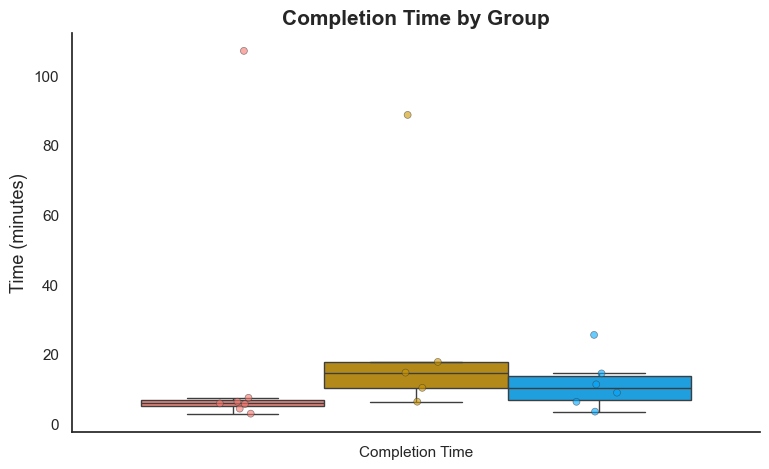

Saved fig3_completion_time


In [4]:
df_fig3 = df[["group_label", "duration_min"]].copy()
df_fig3["metric"] = "Completion Time"

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_fig3, x="metric", y="duration_min", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig3, x="metric", y="duration_min", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Completion Time by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Time (minutes)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
ax.get_legend().remove()

plt.tight_layout()
fig.savefig(OUT_DIR / "fig3_completion_time.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig3_completion_time.pdf", bbox_inches="tight")
plt.show()
print("Saved fig3_completion_time")

## Figure 4 — Self-Assessment by Group

Four x-axis categories: TDI Knowledge (`self_knowledge_tdi`), Avulsion Confidence  
(`self_confidence_avulsion`), Fracture Confidence (`self_confidence_fracture`),  
and Average Self-Assessment (`self_confidence_mean`). y-axis is the 0–10 rating scale.  
These are self-reported Likert ratings; the legend is omitted here (see Figure 1).

**Note:** Statistical between-group comparisons for these variables are reported in  
Table 1 (`02.summary_table.ipynb`) via Kruskal-Wallis tests.

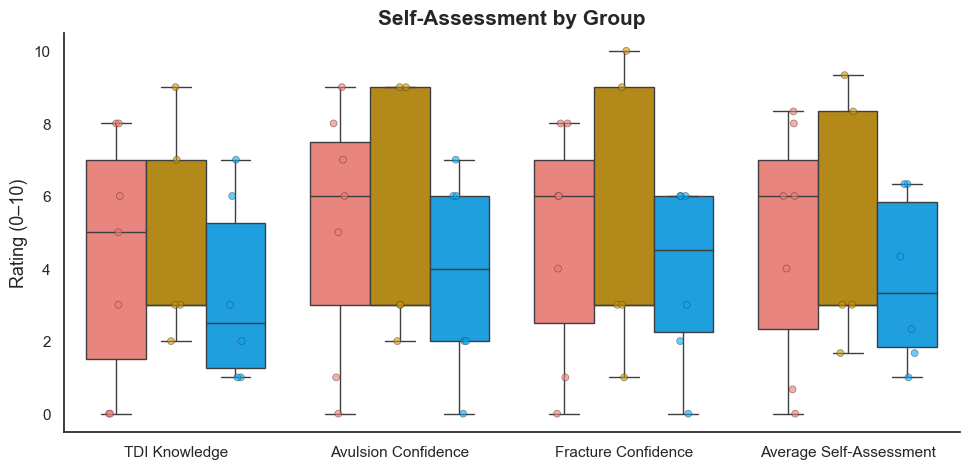

Saved fig4_self_assessment


In [5]:
fig4_vars = {
    "self_knowledge_tdi":        "TDI Knowledge",
    "self_confidence_avulsion":  "Avulsion Confidence",
    "self_confidence_fracture":  "Fracture Confidence",
    "self_confidence_mean":      "Average Self-Assessment",
}
df_fig4 = (
    df[["group_label"] + list(fig4_vars)]
    .melt(id_vars="group_label", var_name="_col", value_name="rating")
    .assign(metric=lambda x: x["_col"].map(fig4_vars))
)
df_fig4["metric"] = pd.Categorical(
    df_fig4["metric"], categories=list(fig4_vars.values()), ordered=True
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_fig4, x="metric", y="rating", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    flierprops=FLIERPROPS, ax=ax,
)
sns.stripplot(
    data=df_fig4, x="metric", y="rating", hue="group_label",
    hue_order=HUE_ORDER, palette=HUE_PALETTE,
    ax=ax, **STRIP_KWS,
)

ax.set_title("Self-Assessment by Group", fontsize=15, fontweight="bold")
ax.set_xlabel("", fontsize=13)
ax.set_ylabel("Rating (0–10)", fontsize=13)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
ax.get_legend().remove()

plt.tight_layout()
fig.savefig(OUT_DIR / "fig4_self_assessment.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(OUT_DIR / "fig4_self_assessment.pdf", bbox_inches="tight")
plt.show()
print("Saved fig4_self_assessment")

---
## Figures 5–8 — Self-Confidence vs Knowledge Score (Scatter Plots)

Each scatter plot shows the relationship between a participant's average self-rated
confidence (`self_confidence_mean`, 0–10 Likert scale) and their total number of
correct answers (`n_correct`, 0–12).

**Why scatter plots?** We have two continuous/ordinal variables and want to examine
whether self-perceived ability aligns with objective performance, both for the
full sample and separately per group. Scatter plots with a linear trend line
(OLS via `seaborn.regplot`) make the direction and strength of the association
immediately visible.

**Statistical annotation:** Each plot is annotated with Spearman's ρ and its
p-value. Spearman's rank correlation is used (rather than Pearson's) because
the Likert-based confidence scale is ordinal and the samples are too small to
verify normality reliably.

**Significance testing for these plots is reported in Table 3** (see
`02.summary_table.ipynb`). The scatter plots serve as a visual complement.

| Figure | Subset            | n  |
|--------|-------------------|----|
| 5      | All Participants  | 18 |
| 6      | No Resource       |  7 |
| 7      | PDF               |  5 |
| 8      | ChatGPT           |  6 |

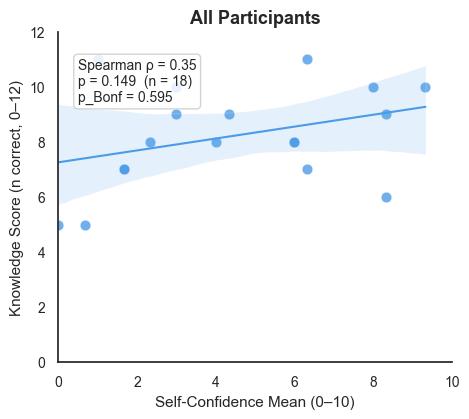

Saved fig5_corr_all


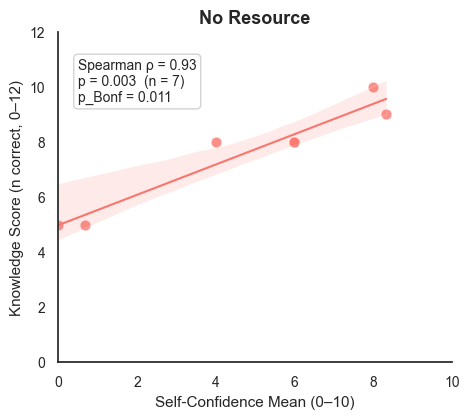

Saved fig6_corr_no_resource


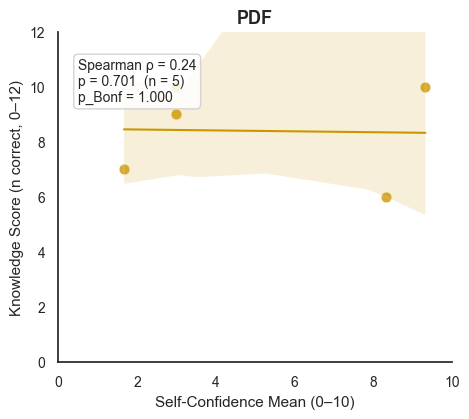

Saved fig7_corr_pdf


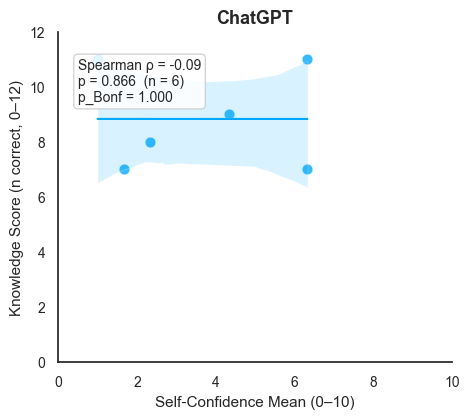

Saved fig8_corr_chatgpt


In [6]:
from scipy.stats import spearmanr

CORR_OUT_DIR = Path("../figures/correlation")
CORR_OUT_DIR.mkdir(parents=True, exist_ok=True)

subsets = [
    ("All Participants", df,                               "#4C9BE8",  "fig5_corr_all"),
    ("No Resource",      df[df["group_label"] == "No Resource"],  HUE_PALETTE["No Resource"], "fig6_corr_no_resource"),
    ("PDF",              df[df["group_label"] == "PDF"],           HUE_PALETTE["PDF"],         "fig7_corr_pdf"),
    ("ChatGPT",          df[df["group_label"] == "ChatGPT"],       HUE_PALETTE["ChatGPT"],     "fig8_corr_chatgpt"),
]

for title, sub, color, stem in subsets:
    valid = sub[["self_confidence_mean", "n_correct"]].dropna()
    n = len(valid)

    fig, ax = plt.subplots(figsize=(5, 4.5))
    fig.patch.set_facecolor("white")

    # Scatter with OLS trend line
    sns.regplot(
        data=valid,
        x="self_confidence_mean",
        y="n_correct",
        ax=ax,
        color=color,
        scatter_kws={"s": 60, "alpha": 0.8, "edgecolors": "white", "linewidths": 0.5},
        line_kws={"linewidth": 1.5},
    )

    if n >= 3:
        rho, pval = spearmanr(valid["self_confidence_mean"], valid["n_correct"])
        p_adj = min(pval * 4, 1.0)  # Bonferroni: 4 tests (all + 3 groups)
        p_str      = f"p = {pval:.3f}"  if pval  >= 0.001 else "p < 0.001"
        p_bonf_str = f"p_Bonf = {p_adj:.3f}" if p_adj >= 0.001 else "p_Bonf < 0.001"
        ax.annotate(
            f"Spearman \u03c1 = {rho:.2f}\n{p_str}  (n = {n})\n{p_bonf_str}",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.85),
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Self-Confidence Mean (0\u201310)", fontsize=11)
    ax.set_ylabel("Knowledge Score (n correct, 0\u201312)", fontsize=11)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.tick_params(labelsize=10)
    sns.despine(ax=ax)

    plt.tight_layout()
    fig.savefig(CORR_OUT_DIR / f"{stem}.png", dpi=600, bbox_inches="tight", transparent=True)
    fig.savefig(CORR_OUT_DIR / f"{stem}.pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved {stem}")
